<a href="https://colab.research.google.com/github/MarceloX2115/Visualizacao_de_dados_reais/blob/main/Visualiza%C3%A7%C3%A3o_de_Dados_de_Kagle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


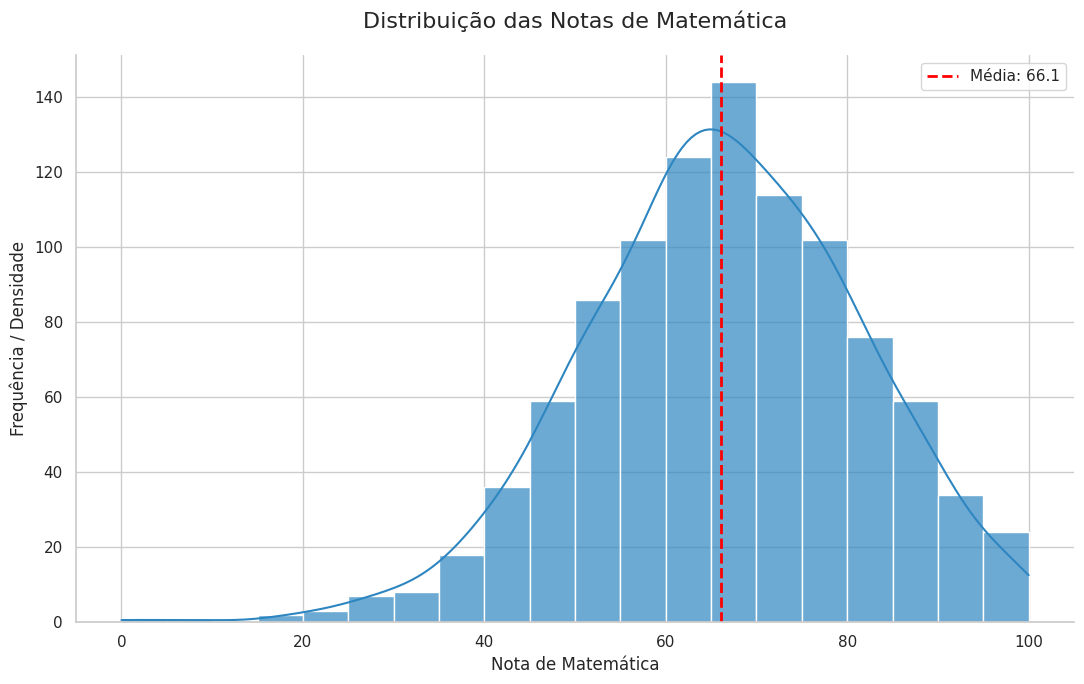

In [3]:
''' Escreva sua justificativa e análise aqui:
1: Qual é a forma da distribuição (simétrica, assimétrica, unimodal, bimodal), onde está o centro (média/mediana) e qual é a dispersão das notas?
2: Histogram com KDE (curva de densidade)
 Justificativa:
 Melhor gráfico para mostrar distribuição de variável quantitativa contínua.
 Permite ver forma, centro e dispersão de forma clara e precisa (From Data to Viz).
 Alta precisão perceptual (Cleveland-McGill) e bom data-ink ratio (Tufte).

4: A distribuição é quase simétrica, com leve assimetria à esquerda.
A maioria das notas se concentra entre 55 e 80, com média próxima de 66-67.
Há uma pequena cauda de notas baixas, mas não há forte bimodalidade. A nota mais comum fica na faixa de 60-70.
'''

# Seu código Python para o gráfico:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 7))
sns.histplot(data=df_performance,
             x='math_score',
             bins=20,
             kde=True,
             color='#2E86C1',
             alpha=0.7)

plt.title('Distribuição das Notas de Matemática', fontsize=16, pad=20)
plt.xlabel('Nota de Matemática', fontsize=12)
plt.ylabel('Frequência / Densidade', fontsize=12)

# Linha vertical da média
mean_score = df_performance['math_score'].mean()
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2,
            label=f'Média: {mean_score:.1f}')

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



/tmp/ipykernel_2207/766304245.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df_performance,
/tmp/ipykernel_2207/766304245.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_performance,


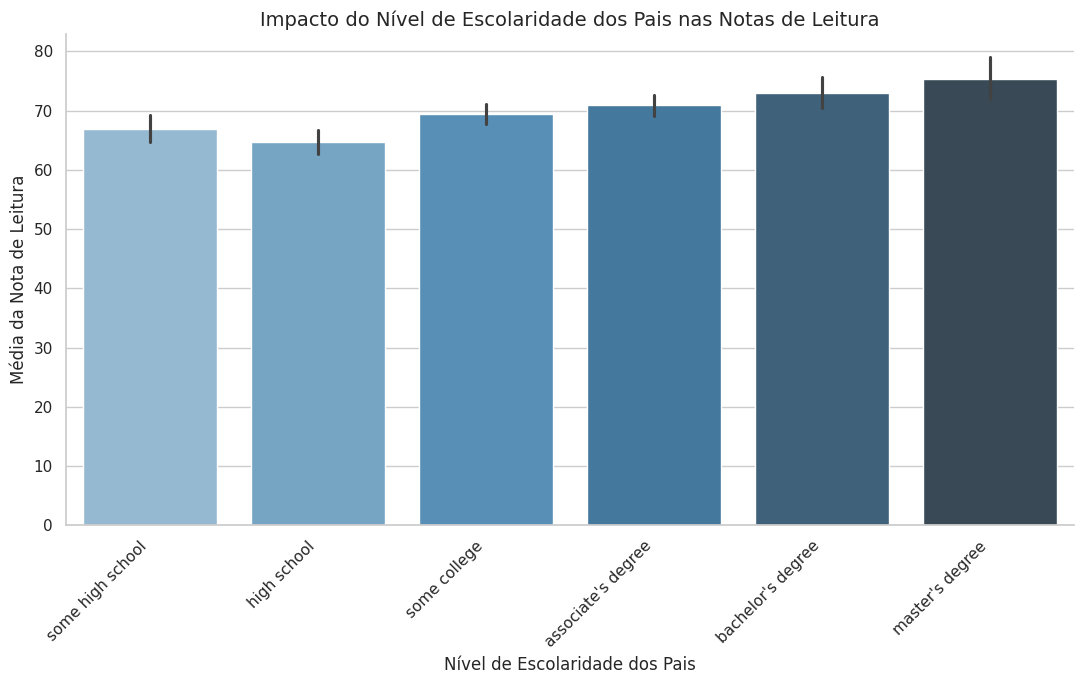

In [4]:
''' Escreva sua justificativa e análise aqui:
1: Existe diferença na média das notas de leitura entre os diferentes níveis de escolaridade dos pais?
2: O bar plot é o gráfico mais adequado para comparar a média de uma variável quantitativa (notas de leitura) entre múltiplas categorias (níveis de escolaridade).
De acordo com a Hierarquia de Cleveland e McGill, posição ao longo de uma escala comum (altura das barras) é o método mais preciso para julgar valores quantitativos,
sendo superior a cores ou áreas. Além disso, permite fácil comparação entre grupos e visualização clara da tendência.

4: O gráfico revela uma tendência clara e positiva: quanto maior o nível de escolaridade dos pais, maior tende a ser a média das notas de leitura dos alunos.
'''

# Seu código Python para o gráfico:
plt.figure(figsize=(11, 7))

# Ordem lógica das categorias de escolaridade
education_order = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

sns.barplot(data=df_performance,
            x='parental_level_of_education',
            y='reading_score',
            order=education_order,
            palette="Blues_d",
            ci=95)   # intervalo de confiança de 95%

plt.title('Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura', fontsize=14)
plt.xlabel('Nível de Escolaridade dos Pais')
plt.ylabel('Média da Nota de Leitura')

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



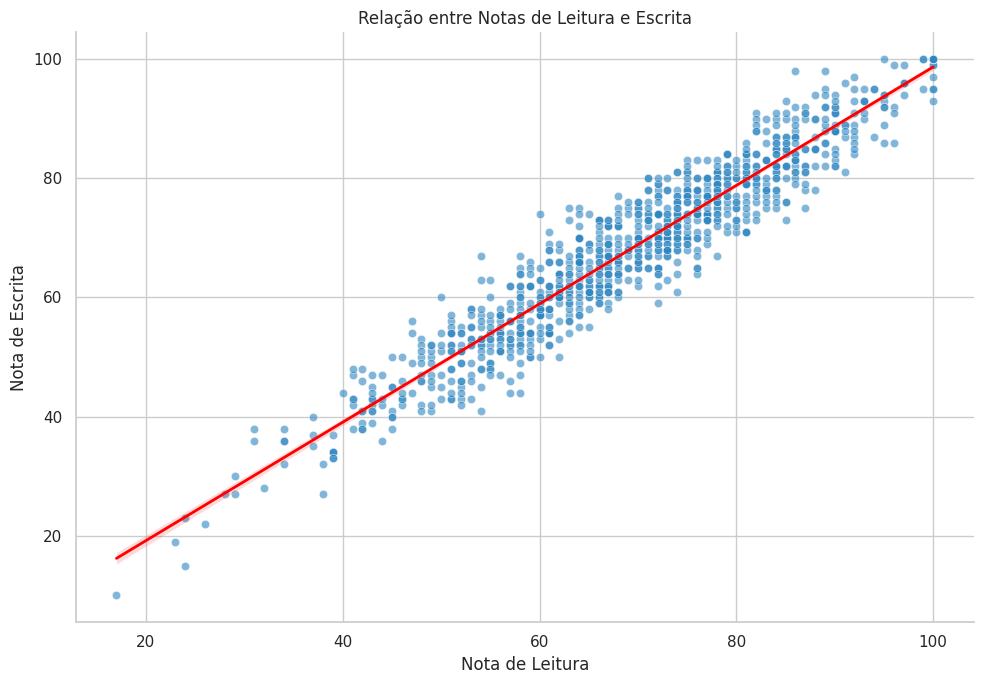

In [5]:
''' Escreva sua justificativa e análise aqui:
1:Qual a força e direção da relação entre as notas de leitura e escrita?
2:Scatter Plot com linha de regressão é o melhor gráfico para mostrar relação entre duas variáveis quantitativas pois oferece alta precisão
perceptiva pela posição dos pontos (Cleveland & McGill).

4:O gráfico confirma forte correlação positiva entre leitura e escrita.
Os pontos seguem uma linha ascendente clara. Poucos outliers e relação bastante linear.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=df_performance,
                x='reading_score',
                y='writing_score',
                alpha=0.6,
                color='#2E86C1')

sns.regplot(data=df_performance,
            x='reading_score',
            y='writing_score',
            scatter=False,
            color='red',
            line_kws={'linewidth': 2})

plt.title('Relação entre Notas de Leitura e Escrita')
plt.xlabel('Nota de Leitura')
plt.ylabel('Nota de Escrita')

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



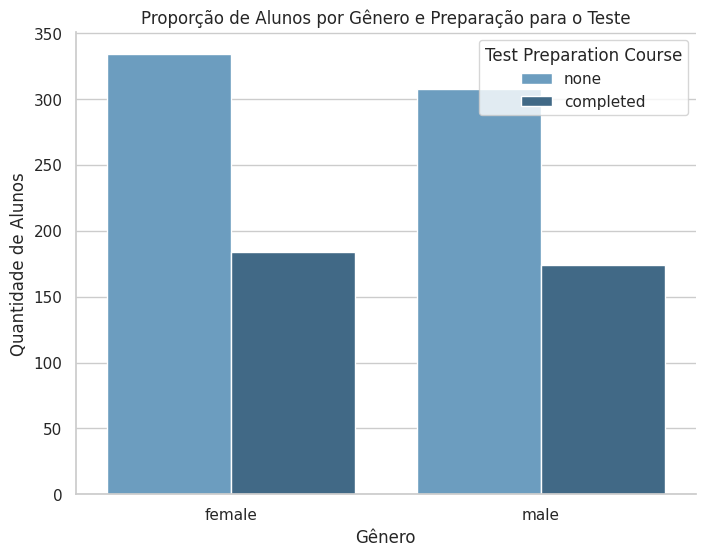

In [6]:
''' Escreva sua justificativa e análise aqui:
1: Qual a proporção de alunos e alunas que completaram o curso de preparação para o teste?
2: Eu usaria o Gráfico de Barras Empilhadas (Stacked Bar Plot) por ser o mais aadequado para comparar proporções entre duas variáveis categóricas,
permitindo visualizar facilmente a distribuição e a comparação entre gêneros de forma clara e compacta.

4:Há uma diferença pequena entre gêneros.
Tanto homens quanto mulheres têm maior proporção de alunos que não completaram o curso de preparação.
As mulheres apresentam uma participação ligeiramente maior no curso de preparação em comparação aos homens.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(8, 6))

sns.countplot(data=df_performance,
              x='gender',
              hue='test_preparation_course',
              palette='Blues_d')

plt.title('Proporção de Alunos por Gênero e Preparação para o Teste')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Alunos')

plt.legend(title='Test Preparation Course')
sns.despine()
plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

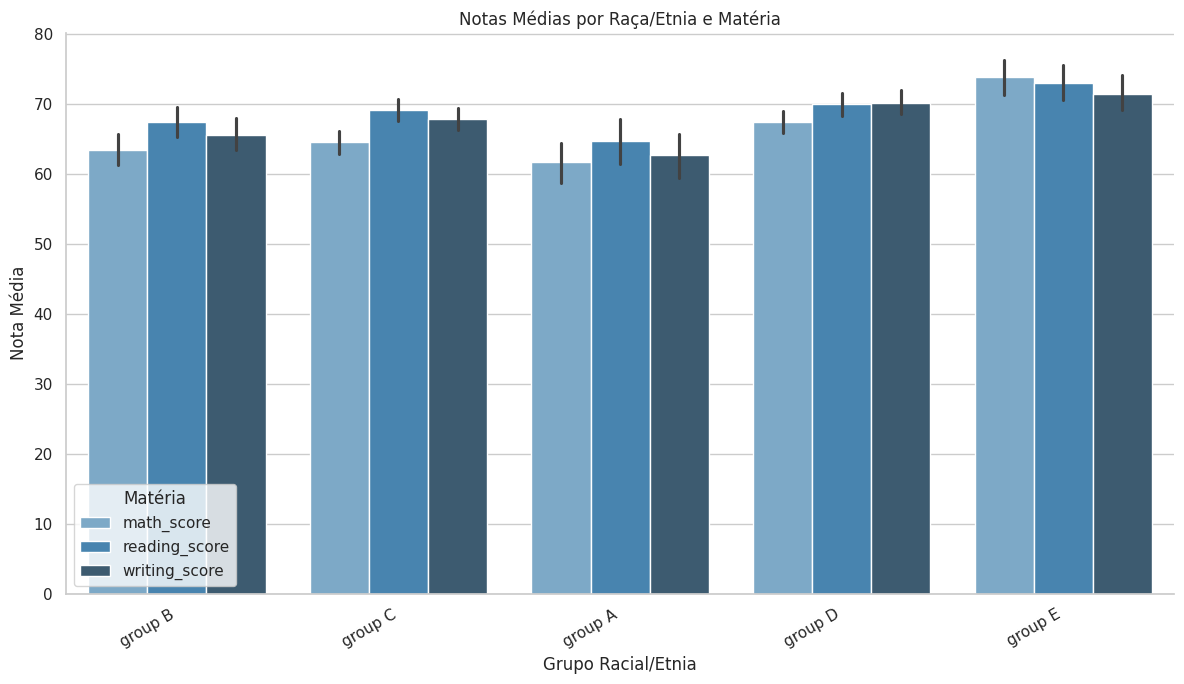

In [7]:
''' Escreva sua justificativa e análise aqui:
1: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?
2: O gráfico de Bar Plot Agrupado (Grouped Bar Plot)
Pois mais adequado para comparar múltiplas variáveis quantitativas (notas das 3 matérias) entre várias categorias nominais (grupos raciais/étnicos),
permitindo uma comparação clara e lado a lado entre grupos e matérias.

4: O grupo "group E" apresenta as maiores médias nas três matérias.
O grupo "group A" tem as menores médias em todas as disciplinas.
Existe um padrão consistente: os grupos com melhor desempenho em uma matéria também tendem a ter melhor desempenho nas outras.
'''

# Seu código Python para o gráfico:
df_melt = df_performance.melt(
    id_vars=['race_ethnicity'],
    value_vars=['math_score', 'reading_score', 'writing_score'],
    var_name='subject',
    value_name='score'
)

plt.figure(figsize=(12, 7))

sns.barplot(data=df_melt,
            x='race_ethnicity',
            y='score',
            hue='subject',
            palette='Blues_d')

plt.title('Notas Médias por Raça/Etnia e Matéria')
plt.xlabel('Grupo Racial/Etnia')
plt.ylabel('Nota Média')

plt.xticks(rotation=30, ha='right')
plt.legend(title='Matéria')
sns.despine()
plt.tight_layout()
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_2207/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


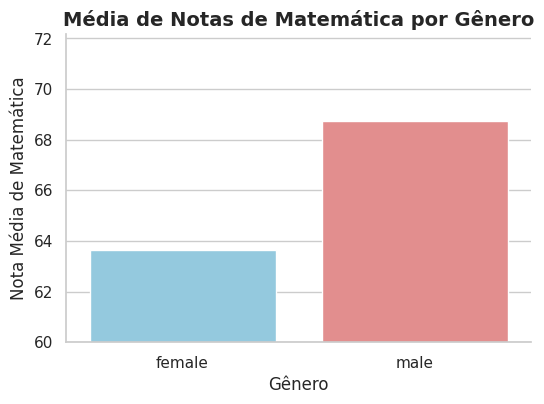

In [9]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

/tmp/ipykernel_2207/4171370265.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="gender",


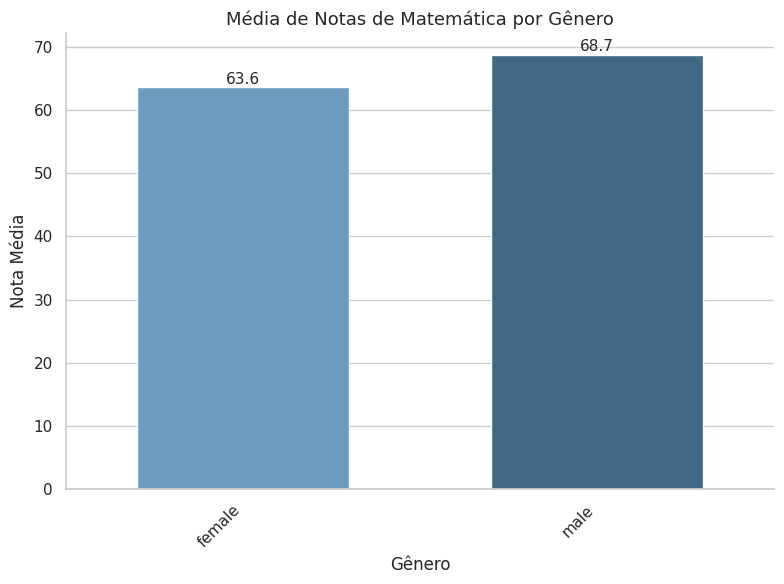

In [10]:
# 1. Problemas identificados:
'''
a) Eixo Y truncado (set_ylim(bottom=60)):
Violação grave do princípio de Tufte (Lie Factor).
A diferença entre os gêneros parece muito maior do que realmente é, induzindo o diretor a concluir que há uma “diferença enorme”.
b) Uso excessivo de cores decorativas (skyblue e lightcoral):
Chartjunk desnecessário. As cores não transmitem informação adicional e distraem do dado principal.
c) Falta de contexto e precisão:
Não mostra os valores reais das médias, não há barras de erro ou intervalo de confiança, e o título é exagerado (“bold”).
Viola princípios de clareza e honestidade (Tufte e Cleveland-McGill).
'''

# 2. Seu código Python refatorado:
plt.figure(figsize=(8, 6))

sns.barplot(x="gender",
            y="math_score",
            data=df_gender_math,
            palette="Blues_d",
            width=0.6)

# Adiciona os valores exatos no topo das barras
for i, v in enumerate(df_gender_math["math_score"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=11)

plt.title("Média de Notas de Matemática por Gênero", fontsize=13)
plt.xlabel("Gênero")
plt.ylabel("Nota Média")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, None)

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_2207/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


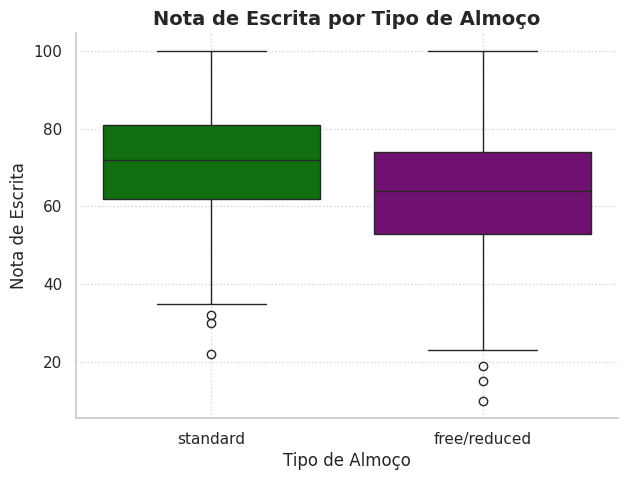

In [12]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

/tmp/ipykernel_2207/4080757377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lunch",


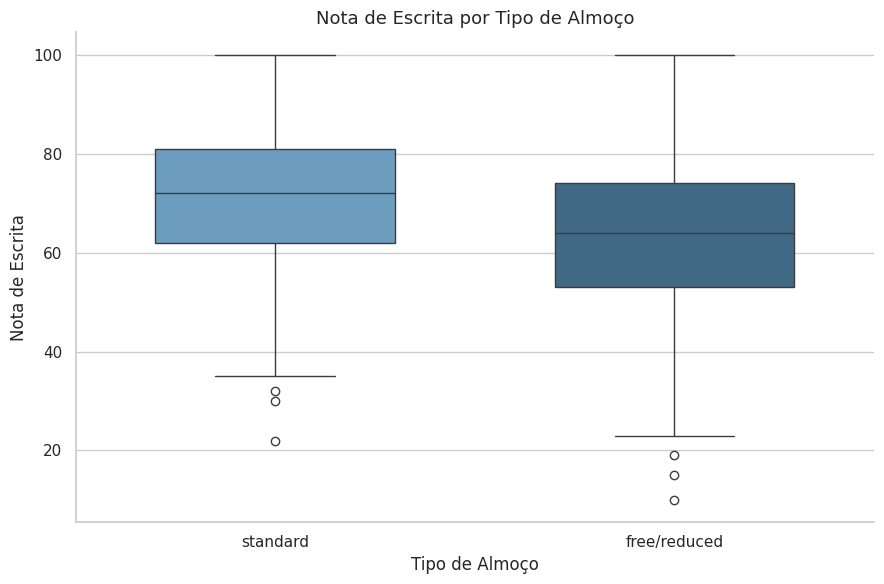

In [13]:
# 1. Problemas identificados:
'''
a) Chartjunk excessivo:
   Grade pesada (grid=True) com linhas pontilhadas que não agregam informação útil e poluem o gráfico (baixa Data-Ink Ratio - Tufte).
b) Cores ineficazes e decorativas:
   Uso de "green" e "purple" não tem significado claro e distraem a atenção. As cores não ajudam na comparação.
c) Título e elementos visuais exagerados:
   Fonte em negrito muito forte e título desnecessariamente chamativo, violando o princípio de simplicidade e foco nos dados.
'''
# 2. Seu código Python refatorado:
plt.figure(figsize=(9, 6))

sns.boxplot(x="lunch",
            y="writing_score",
            data=df_performance,
            palette="Blues_d",
            width=0.6)

plt.title("Nota de Escrita por Tipo de Almoço", fontsize=13)
plt.xlabel("Tipo de Almoço")
plt.ylabel("Nota de Escrita")

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_2826/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


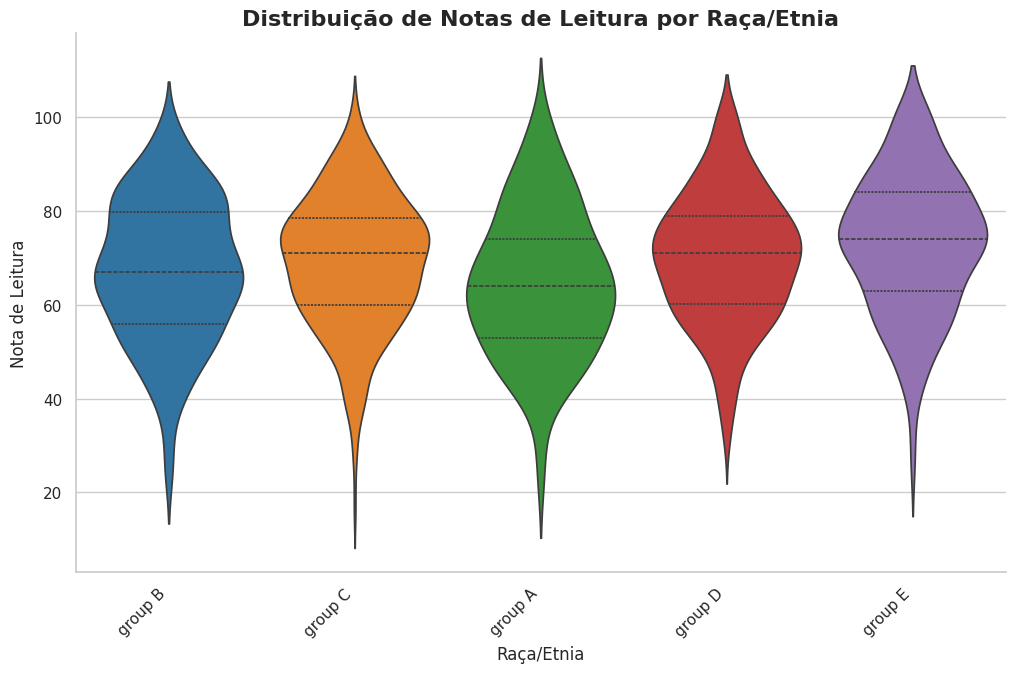

In [ ]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_2207/479375060.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


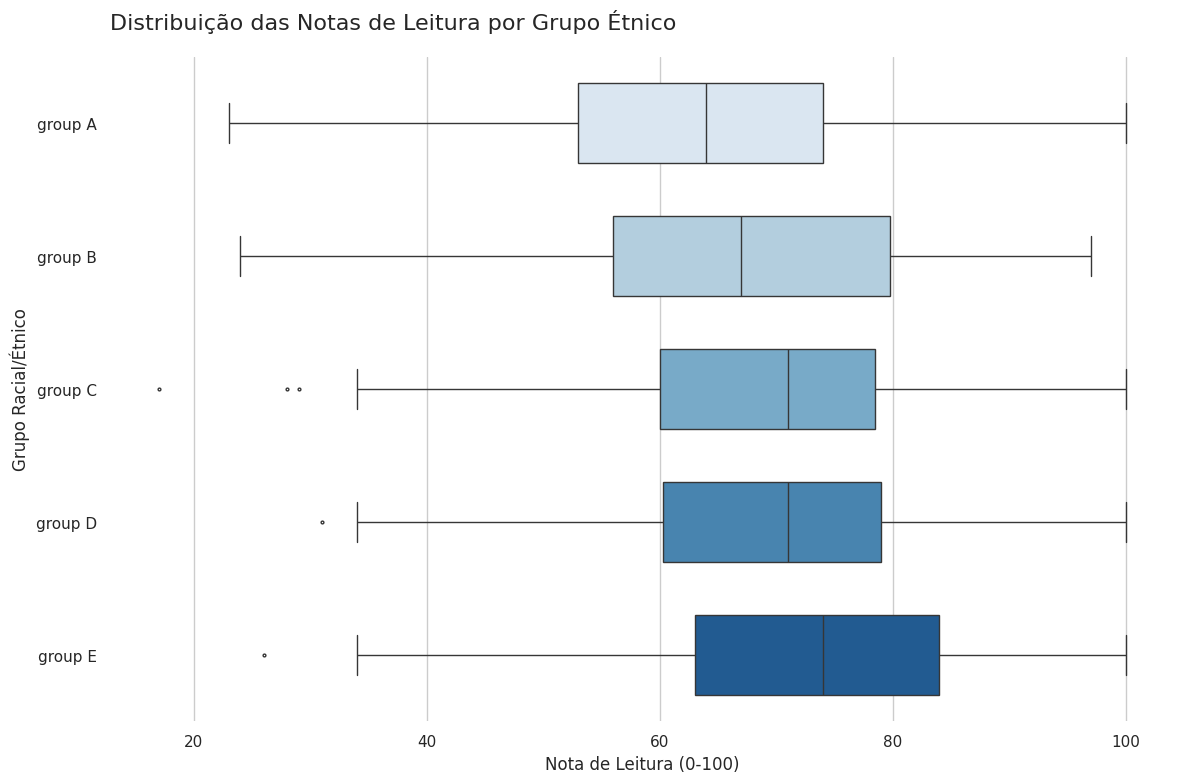

In [15]:
# 1. Problemas identificados:
'''
a)Excesso de "Non-Data Ink" (Tufte): O uso de múltiplas cores (paleta tab10)
  para categorias que já estão separadas no eixo X polui o gráfico sem adicionar informação útil.
b)Dificuldade de Comparação (Cleveland-McGill): A disposição alfabética dos grupos impede uma comparação rápida de desempenho.
  O olho humano identifica padrões muito melhor quando os dados estão ordenados por uma métrica (como a mediana).
c)Poluição Visual (Gestalt/Chartjunk): O violinplot com quartetos internos em um gráfico denso cria muitas micro-linhas que competem pela atenção,
 dificultando a percepção da tendência central de cada grupo.
'''
# 2. Seu código Python refatorado:

# Ordenando os grupos pela mediana para facilitar a comparação
order = df_performance.groupby("race_ethnicity")["reading_score"].median().sort_values().index

# Configuração do Estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Refatoração: Usando um Boxplot mais limpo com largura controlada
# ou um Ridgeline plot para evitar a sobrecarga do Violin
ax = sns.boxplot(
    x="reading_score",
    y="race_ethnicity",
    data=df_performance,
    order=order,
    palette="Blues",
    width=0.6,
    fliersize=2
)

# Refinamento Estético e Clareza
plt.title("Distribuição das Notas de Leitura por Grupo Étnico", fontsize=16, loc='left', pad=20)
plt.xlabel("Nota de Leitura (0-100)", fontsize=12)
plt.ylabel("Grupo Racial/Étnico", fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

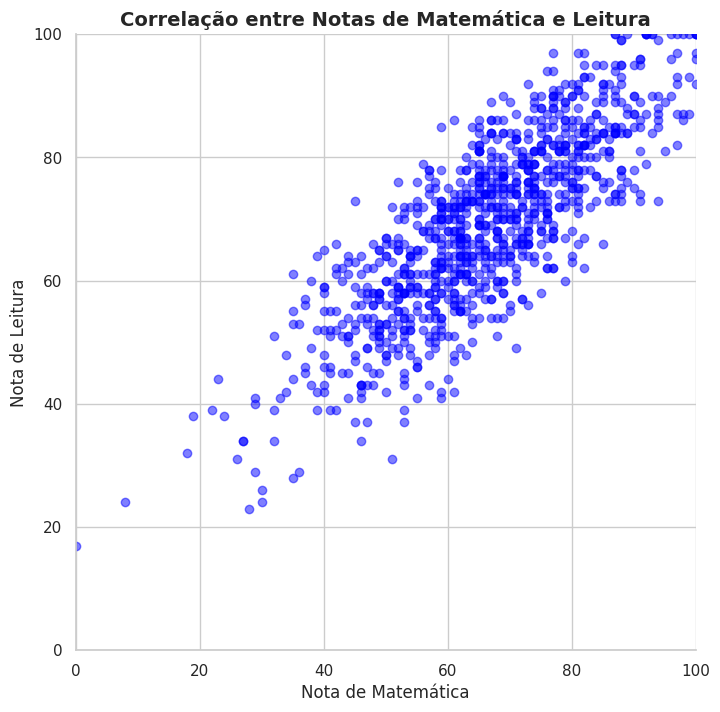

In [ ]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

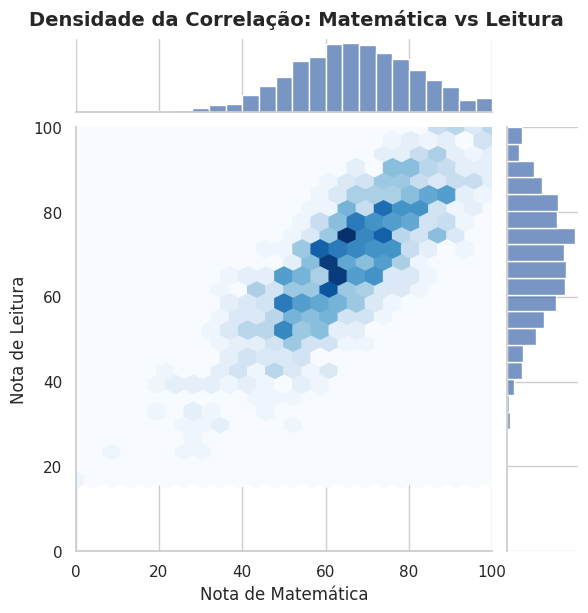

In [18]:
# 1. Problemas identificados:
'''
a) Overplotting (Sobreposição): Mesmo com o alpha=0.5, a alta concentração de dados em certas áreas cria massas de cor sólida,
impossibilitando distinguir onde há 10 ou 100 alunos com a mesma nota.
b) Baixa Percepção de Densidade (Cleveland-McGill): O cérebro humano tem dificuldade em estimar a densidade local em scatter plots saturados. ]
Não é possível identificar com precisão o "centro" da massa de dados (o ponto de maior frequência).
c) Falta de Distribuições Marginais: Um gráfico de dispersão simples mostra a correlação, mas falha em mostrar simultaneamente como cada nota se distribui
individualmente (univariada), o que ajudaria a contextualizar a correlação.
'''
# 2. Seu código Python refatorado:

# Refatoração usando Jointplot com Hexbin para lidar com a densidade
g = sns.jointplot(
    data=df_performance,
    x="math_score",
    y="reading_score",
    kind="hex",
    cmap="Blues",
    marginal_kws=dict(fill=True)
)

# Ajustes de títulos e labels
g.fig.suptitle("Densidade da Correlação: Matemática vs Leitura", fontsize=14, fontweight="bold", y=1.02)
g.set_axis_labels("Nota de Matemática", "Nota de Leitura")

# Limites para manter a escala honesta
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

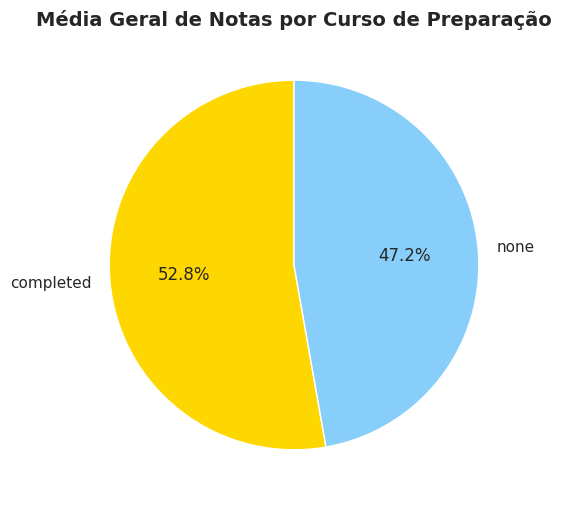

In [ ]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

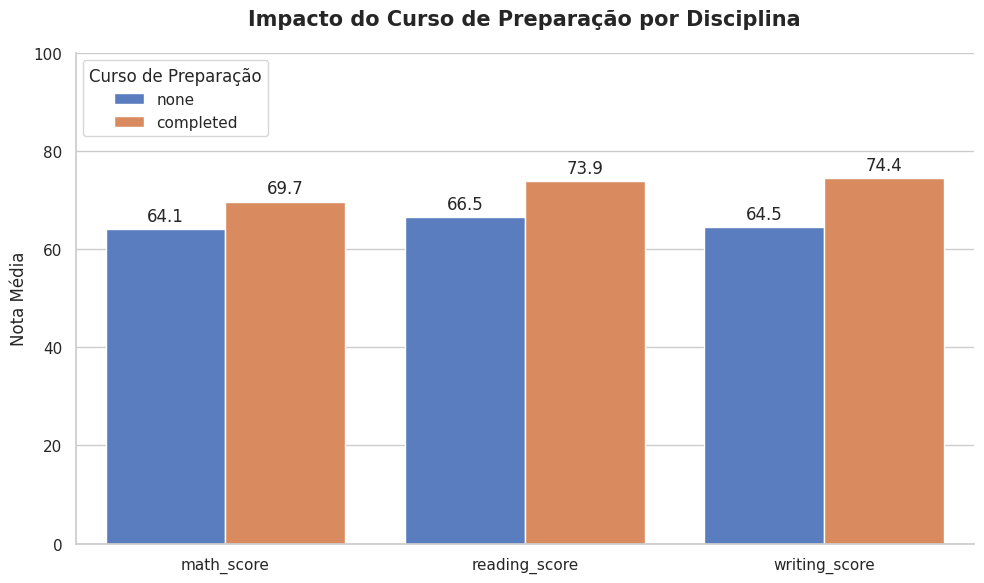

In [19]:
# 1. Problemas identificados:
'''
a) Redundância de Cores (Tufte): O uso de uma cor diferente para cada barra/violino não acrescenta informação, já que os grupos já estão separados no eixo.
Isso cria uma carga cognitiva desnecessária.
b) Falta de Hierarquia (Cleveland-McGill): Ao manter os grupos em ordem alfabética, o gráfico falha em mostrar rapidamente quem performa melhor ou pior.
A ordenação por mediana resolve isso.
c) Ruído Visual (Gestalt): O violino com linhas internas de quartis cria muitas formas pequenas que competem entre si,
dificultando a visualização da distribuição geral em um relance.
'''
# 2. Seu código Python refatorado:

# Preparando dos dados: Transformar para formato longo (tidy) para comparar as 3 matérias
df_melted = df_performance.melt(
    id_vars="test_preparation_course",
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="Subject",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

# Refatorando o Gráfico de barras agrupado para comparação direta e detalhada
ax = sns.barplot(
    data=df_melted,
    x="Subject",
    y="Score",
    hue="test_preparation_course",
    palette="muted",
    errorbar=None # Foco na média, conforme solicitado
)

# Refinando de Design (Princípios de Tufte e Gestalt)
plt.title("Impacto do Curso de Preparação por Disciplina", fontsize=15, fontweight="bold", pad=20)
plt.ylabel("Nota Média")
plt.xlabel("")
plt.ylim(0, 100) # Mantém a escala honesta
plt.legend(title="Curso de Preparação", loc="upper left")

# Adicionando rótulos de dados para aumentar o Data-Ink Ratio útil
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()